<a href="https://colab.research.google.com/github/GBakalkinOAI/DDLS2024/blob/main/23_census_access_maintained_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Access CELLxGENE collaboration embeddings (scVI, Geneformer)

This notebook demonstrates basic access to CELLxGENE collaboration embeddings of CELLxGENE Discover Census. Currently, embeddings from scVI and a fine-tuned Geneformer model are maintained by CELLxGENE Discover. There are other CELLxGENE-hosted embeddings contributed by the community to CELLxGENE Discover, find out more about these in the [Census model page](https://cellxgene.cziscience.com/census-models).

**IMPORTANT:** This tutorial requires cellxgene-census package version 1.9.1 or later.

**Contents**

1. Quick start
1. Storage format
1. Query cells and load associated embeddings

⚠️ Note that the Census RNA data includes duplicate cells present across multiple datasets. Duplicate cells can be filtered in or out using the cell metadata variable `is_primary_data` which is described in the [Census schema](https://github.com/chanzuckerberg/cellxgene-census/blob/main/docs/cellxgene_census_schema.md#repeated-data).


## Quick start

CELLxGENE collaboration embeddings can easily be exported into an AnnData as shown below for any slice of Census. This example queries all cells from tongue tissue.

⚠️ Note that Geneformer embeddings are only available for human data

In [ ]:
# Installation commands are taken from: https://docs.scvi-tools.org/en/latest/tutorials/notebooks/hub/cellxgene_census_model.html
# See also: https://chanzuckerberg.github.io/cellxgene-census/cellxgene_census_docsite_installation.html
!pip install --quiet scvi-colab
!pip install --quiet cellxgene-census
!pip install --quiet pybiomart # is gene chrY-related?
from scvi_colab import install
install()
!pip install owlready2 # ontology processing

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.6/179.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.0/129.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.6/83.6 kB 6.2 MB/s eta 0:00:00
ERROR: pip's depe

In [ ]:
# Import necessary libraries
import cellxgene_census
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import scvi
from owlready2 import *

In [ ]:
import cellxgene_census

emb_names = ["scvi", "geneformer"]
census_version = "2023-12-15"

with cellxgene_census.open_soma(census_version=census_version) as census:
    adata = cellxgene_census.get_anndata(
        census,
        organism="homo_sapiens",
        measurement_name="RNA",
        obs_value_filter="tissue == 'tongue'",
        obs_embeddings=emb_names,
    )

In [ ]:
adata

AnnData object with n_obs × n_vars = 372 × 60664
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_length', 'nnz', 'n_measured_obs'
    obsm: 'scvi', 'geneformer'

In [ ]:
adata.obsm

AxisArrays with keys: scvi, geneformer

## Storage format

Each embedding is encoded as a SOMA SparseNDArray, where:

* dimension 0 (`soma_dim_0`) encodes the cell (obs) `soma_joinid` value
* dimension 1 (`soma_dim_1`) encodes the embedding feature, and is in the range [0, N) where N is the number of features in the embedding
* data (`soma_data`) is float32

The first axis of the embedding array will have the same shape as the corresponding `obs` DataFrame for the Census build and experiment. The second axis of the embedding will have a shape (0, N) where N is the number of features in the embedding.

Embedding values, while stored as a float32, are precision reduced. Currently they are equivalent to a bfloat16, i.e., have 8 bits of exponent and 7 bits of mantissa.

## Query cells and load associated embeddings

This section demonstrates several methods to query cells from the Census by `obs` metadata, and then fetch embeddings associated with each cell.


### Loading embeddings into an AnnData `obsm` slot

There are two main ways to load CELLxGENE collaboration embeddings into an AnnData.

1. Via `cellxgene_census.get_anndata()`.
2. With a lazy query via `ExperimentAxisQuery`.

#### AnnData embeddings via `cellxgene_census.get_anndata()`

This is the simplest way of getting the embeddings. In this example we create an AnnData for all "central nervous system" cells.

In [ ]:
import warnings

import cellxgene_census
import scanpy

warnings.filterwarnings("ignore")

census_version = "2023-12-15"
census = cellxgene_census.open_soma(census_version=census_version)

emb_names = ["scvi", "geneformer"]

adata = cellxgene_census.get_anndata(
    census,
    organism="homo_sapiens",
    measurement_name="RNA",
    obs_value_filter="tissue_general == 'central nervous system'",
    obs_column_names=["cell_type"],
    obs_embeddings=emb_names,
)

census.close()

Then we can take a quick look at the embeddings in a 2D scatter plot via UMAP.

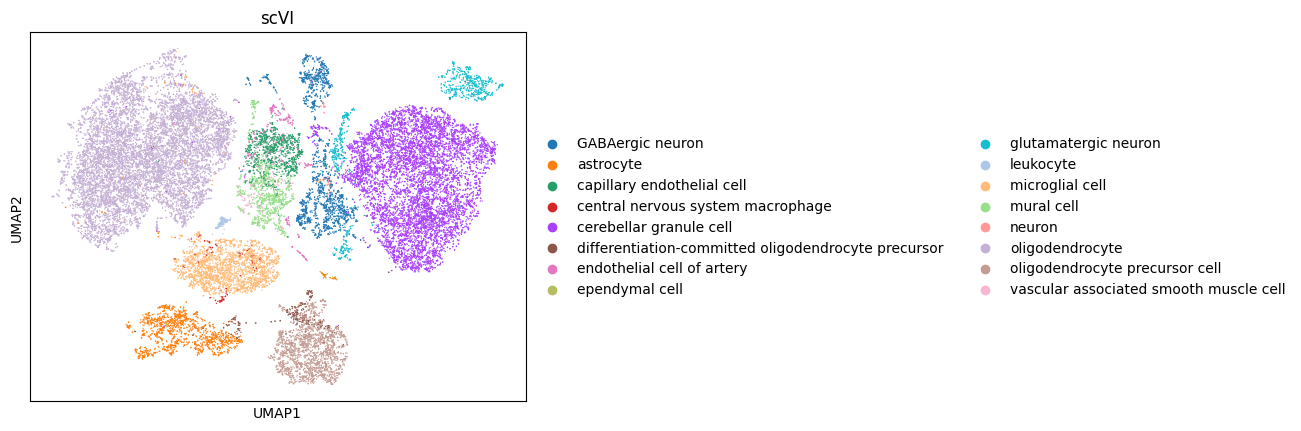

In [ ]:
scanpy.pp.neighbors(adata, use_rep="scvi")
scanpy.tl.umap(adata)
scanpy.pl.umap(adata, color="cell_type", title="scVI")

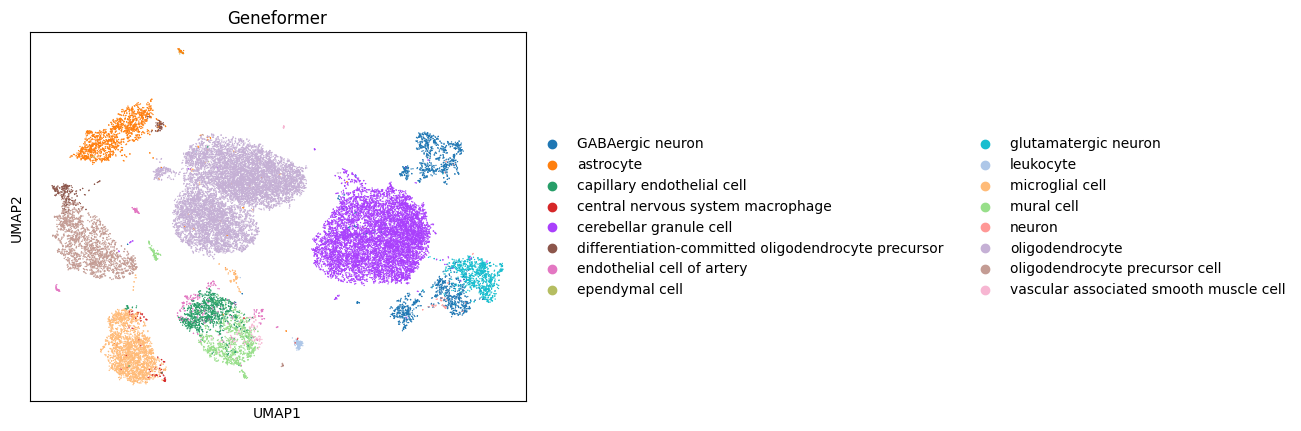

In [ ]:
scanpy.pp.neighbors(adata, use_rep="geneformer")
scanpy.tl.umap(adata)
scanpy.pl.umap(adata, color="cell_type", title="Geneformer")

#### AnnData embeddings via `ExperimentAxisQuery`

Using an `ExperimentAxisQuery` to get embeddings into an AnnData has the main advantage of inspecting the query in a lazy manner before loading all data into AnnData.

As a reminder this class offers a lazy interface to query Census based on cell and gene metadata, and provides access to the correspondong expression data, cell/gene metadata, and the embeddings.

Let's initiate a lazy query with the same filters as the previous example.

In [ ]:
import cellxgene_census
import scanpy
import tiledbsoma as soma

census_version = "2023-12-15"
organism = "homo_sapiens"

census = cellxgene_census.open_soma(census_version=census_version)

experiment = census["census_data"][organism]
query = experiment.axis_query(
    measurement_name="RNA",
    obs_query=soma.AxisQuery(value_filter="tissue_general == 'central nervous system'"),
)

Now, before downloading all the data we can take a look at different attributes, for example the number of cells in our query.

In [ ]:
query.n_obs

31780

In [ ]:
# Read the observation data and convert to a pandas DataFrame
obs_df = query.obs().concat().to_pandas()
print(obs_df.head())

   soma_joinid                            dataset_id      assay  \
0      8752190  c8f83821-a242-4ed7-86e9-7da077f5d348  10x 3' v3   
1      8752191  c8f83821-a242-4ed7-86e9-7da077f5d348  10x 3' v3   
2      8752192  c8f83821-a242-4ed7-86e9-7da077f5d348  10x 3' v3   
3      8752193  c8f83821-a242-4ed7-86e9-7da077f5d348  10x 3' v3   
4      8752194  c8f83821-a242-4ed7-86e9-7da077f5d348  10x 3' v3   

  assay_ontology_term_id       cell_type cell_type_ontology_term_id  \
0            EFO:0009922  ependymal cell                 CL:0000065   
1            EFO:0009922       astrocyte                 CL:0000127   
2            EFO:0009922       astrocyte                 CL:0000127   
3            EFO:0009922       astrocyte                 CL:0000127   
4            EFO:0009922       astrocyte                 CL:0000127   

         development_stage development_stage_ontology_term_id disease  \
0  34-year-old human stage                     HsapDv:0000128  normal   
1  34-year-old human sta

In [ ]:
# Read the variable (gene) data and convert to a pandas DataFrame
var_df = query.var().concat().to_pandas()
print(var_df.head())

   soma_joinid       feature_id feature_name  feature_length      nnz  \
0            0  ENSG00000233576      HTR3C2P            1057    69370   
1            1  ENSG00000121410         A1BG            3999  5640476   
2            2  ENSG00000268895     A1BG-AS1            3374  3071864   
3            3  ENSG00000148584         A1CF            9603   734347   
4            4  ENSG00000175899          A2M            6318  7894261   

   n_measured_obs  
0        19581263  
1        62641311  
2        61946057  
3        58195911  
4        62704378  


Then we create an AnnData, retrieve the embeddings and add them to the AnnData's obsm slot:

In [ ]:
from cellxgene_census.experimental import get_embedding, get_embedding_metadata_by_name

emb_names = ["scvi", "geneformer"]

adata = query.to_anndata(X_name="raw", column_names={"obs": ["cell_type"]})

for embedding_name in ["scvi", "geneformer"]:
    metadata = get_embedding_metadata_by_name(embedding_name, "homo_sapiens", census_version=census_version)
    embedding_uri = (
        f"s3://cellxgene-contrib-public/contrib/cell-census/soma/{metadata['census_version']}/{metadata['id']}"
    )
    embedding = get_embedding(metadata["census_version"], embedding_uri, query.obs_joinids().to_numpy())
    adata.obsm[embedding_name] = embedding

adata

AnnData object with n_obs × n_vars = 31780 × 60664
    obs: 'cell_type', 'tissue_general'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_length', 'nnz', 'n_measured_obs'
    obsm: 'scvi', 'geneformer'

In [ ]:
adata

AnnData object with n_obs × n_vars = 31780 × 60664
    obs: 'cell_type', 'tissue_general'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_length', 'nnz', 'n_measured_obs'
    obsm: 'scvi', 'geneformer'

In [ ]:
query.close()
census.close()

In [ ]:
# Print the entire metadata dictionary
print(metadata)

{'id': 'CxG-czi-1', 'title': 'Geneformer embeddings fine-tuned for CELLxGENE Census cell subclass classification', 'description': "Geneformer is a foundation transformer model pretrained on a large-scale corpus of ~30 million single cell transcriptomes to enable context-aware predictions in settings with limited data in network biology. These cell embeddings are derived from a Geneformer model CZI fine-tuned for cell subclass classification. As the fine-tuning procedure remains experimental and wasn't performed by the Geneformer authors, these embeddings should not be used to assess performance of the Geneformer pre-trained model.", 'embedding_name': 'geneformer', 'primary_contact': {'name': 'CELLxGENE Discover Team', 'email': 'soma@chanzuckerberg.com', 'affiliation': 'CZI'}, 'additional_contacts': [], 'DOI': '10.1038/s41586-023-06139-9', 'additional_information': "Beginning with the geneformer-12L-30M pretrained model published by Theodoris et al. (huggingface.co/ctheodoris/Geneformer

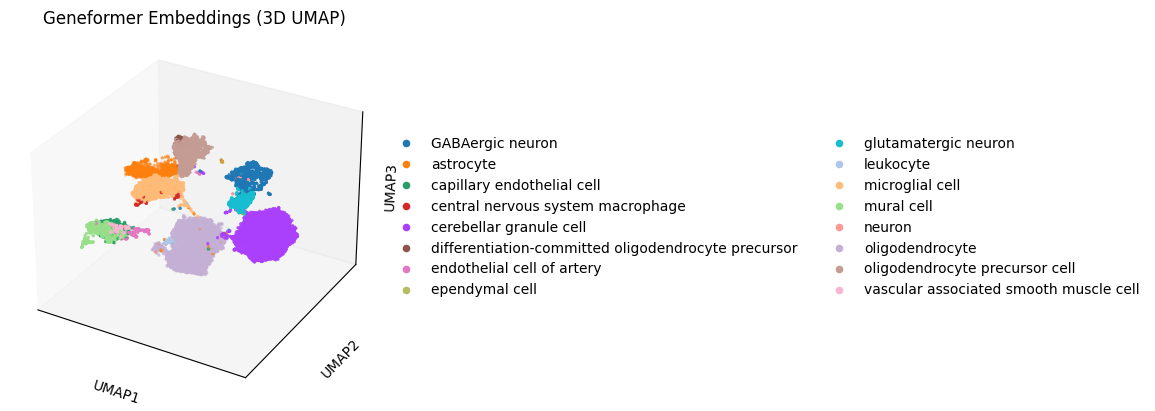

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # This import registers the 3D projection

# Compute the neighbor graph using the 'geneformer' embeddings
sc.pp.neighbors(adata, use_rep='geneformer')

# Compute the UMAP embedding in 3D
sc.tl.umap(adata, n_components=3)

# Visualize the 3D UMAP
sc.pl.umap(adata, color='cell_type', title='Geneformer Embeddings (3D UMAP)', projection='3d')


### Load an embedding into a dense NumPy array

To load a  embeddinng into a stand-alone numpy array you can select cells from the Census based on obs metadata, then given the resulting cells, use the `soma_joinid` values to download an embedding, and finally save as a dense NDArray.

Let's first select cells based on cell metadata.

In [ ]:
import cellxgene_census
import tiledbsoma as soma

census_version = "2023-12-15"
experiment_name = "homo_sapiens"

census = cellxgene_census.open_soma(census_version=census_version)

obs_df = cellxgene_census.get_obs(
    census,
    experiment_name,
    value_filter="tissue_general == 'central nervous system'",
    column_names=["soma_joinid", "cell_type"],
)

Now you can use the `soma_joinid` values to download the corresponding rows of the embedding matrix via `get_embedding`.

In [ ]:
metadata = get_embedding_metadata_by_name("scvi", experiment_name, census_version=census_version)
embedding_uri = f"s3://cellxgene-contrib-public/contrib/cell-census/soma/{metadata['census_version']}/{metadata['id']}"
embedding = get_embedding(metadata["census_version"], embedding_uri, obs_df.soma_joinid.to_numpy())

And now we have a dense matrix with the embedding data.

In [ ]:
embedding

array([[-6.17187500e-01,  3.82995605e-03, -7.50000000e-01, ...,
         7.50000000e-01,  9.39941406e-03,  2.71606445e-03],
       [ 3.39843750e-01,  4.71115112e-04, -8.32031250e-01, ...,
         8.00781250e-01, -7.55310059e-04,  8.85009766e-03],
       [ 4.10156250e-01, -2.42614746e-03, -5.00000000e-01, ...,
         9.45312500e-01, -2.53295898e-03,  1.12915039e-02],
       ...,
       [ 3.84765625e-01, -1.54113770e-03, -1.94531250e+00, ...,
        -2.38281250e-01, -1.03149414e-02,  2.28881836e-03],
       [ 8.94531250e-01, -7.14111328e-03,  5.78125000e-01, ...,
        -1.15234375e-01, -2.39562988e-03,  2.42614746e-03],
       [ 6.79687500e-01, -8.48388672e-03,  1.45312500e+00, ...,
        -1.19628906e-01,  6.62803650e-05, -1.88446045e-03]], dtype=float32)

In [ ]:
embedding.shape

(31780, 50)

In [ ]:
query.close()
census.close()